## Libraries

In [ ]:
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt
import shutil
import random

random.seed(7)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PATH = '/content/sample_data/Data/'
BASE_PATH = '/content/sample_data/'
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/03b - MultipleDetection-PCB/'

In [ ]:
!unzip -q '/content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/03b - MultipleDetection-PCB/Data/Original Images.zip' -d '/content/sample_data/Data'

YOLO ANNOTATIONS FORMAT: class, x_center, y_center, width, height

DATA FORMAT IN THE FILES PROVIDED: x_min, y_min, x_max, y_max, class

In [ ]:
# OBTAIN PATH TO ALL OBJECTS

path_origin = PATH+'Original Images'

items_paths = []

groups_folders = os.listdir(path_origin)

for folder in groups_folders:
    subfolders = os.listdir(os.path.join(path_origin, folder))

    for subfolder in subfolders:
        items = os.listdir(os.path.join(os.path.join(path_origin, folder), subfolder))

        for item in items:
            items_paths.append(os.path.join(os.path.join(os.path.join(path_origin, folder), subfolder), item))

print(len(items_paths))

4501


In [ ]:
# SPLIT BETWEEN ANNOTATIONS AND IMAGES

annotations_path = []
images_path = []

for item_path in items_paths:
    if '_not' in item_path:
        annotations_path.append(item_path)

    if '_test' in item_path:
        images_path.append(item_path)

In [ ]:
# CHECK LENGTH

print(len(images_path))
print(len(annotations_path))

1500
1500


In [ ]:
images_path[50]

'/content/sample_data/Data/Original Images/group12300/12300/12300144_test.jpg'

In [ ]:
# SPLIT THE PATH TO OBTAIN ONLY THE IMAGE NAME

words = images_path[50].split('/')
words[-1]


'12300144_test.jpg'

In [ ]:
# OBTAIN ONLY THE CODE FOR THE IMAGE

image_name = words[-1].replace('_test.jpg', '')
image_name

'12300144'

In [ ]:
# SEARCH FOR THE ANNOTATION OF THE IMAGE

for annotation in annotations_path:

    if image_name in annotation:
        break
annotation

'/content/sample_data/Data/Original Images/group12300/12300_not/12300144.txt'

In [ ]:
# READ TH FILE

with open(annotation, 'r') as content:
    details = content.readlines()

details

['166 324 214 354 1\n',
 '449 594 503 629 2\n',
 '426 225 464 252 5\n',
 '479 132 511 162 6\n',
 '300 180 330 215 3\n',
 '150 191 197 229 2\n']

In [ ]:
# CLASS DICTIONARY FROM GITHUB (https://github.com/tangsanli5201/DeepPCB)

dict_classes = {1: 'open', 2: 'short', 3: 'mousebite', 4: 'spur', 5: 'copper', 6: 'pin-hole'}

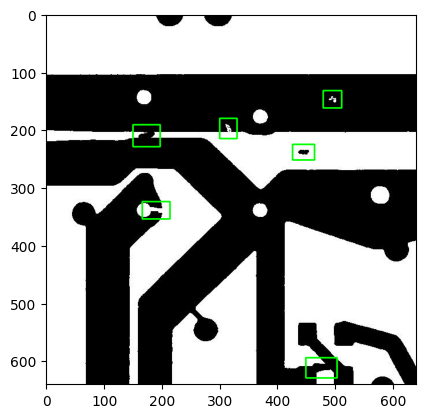

In [ ]:
# DRAW ANNOTATIONS IN THE IMAGE

image = images_path[50]
label = details

image = cv2.imread(image)

for detail in details:

    splitted = detail.split()
    x1 = int(splitted[0])
    x2 = int(splitted[2])
    y1 = int(splitted[1])
    y2 = int(splitted[3])

    rectangle_image = cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(rectangle_image)

In [ ]:
# AS WE CHECK THE FORMAT OF THE ANNOTATION, LET'S TRANSLATE IT TO YOLO FORMAT

def to_yolo(image_path, annotations_path, folder_path):

    yolo_out = []

    image = cv2.imread(image_path)
    h, w, c = image.shape

    cadena = ''.join(image_path)

    words = cadena.split('/')
    image_name = words[-1].replace('_test.jpg', '')

    for annotation in annotations_path:

        if image_name in annotation:
            break

    with open(annotation, 'r') as content:
        details = content.readlines()

    for detail in details:

        splitted = detail.split()
        x1 = int(splitted[0])
        x2 = int(splitted[2])
        y1 = int(splitted[1])
        y2 = int(splitted[3])
        label = int(splitted[4])-1 # CLASSES STARTS WITH 0 IN YOLO

        x_center = (x2 + x1) / (2*w)
        y_center = (y2 + y1) / (2*h)
        width = (x2-x1) / w
        height = (y2-y1) / h

        yolo_out.append([label, x_center, y_center, width, height])

    shutil.copy(image_path, os.path.join(folder_path, 'images/' + image_name + '.jpg'))

    with open(folder_path + '/labels/' + image_name + '.txt', 'w') as archivo:
        for line in yolo_out:
            for w in line:
                archivo.write(str(w))
                archivo.write(' ')
            archivo.write('\n')

    return yolo_out

In [ ]:
total_images = len(images_path)

train_number = int(total_images * 0.7)

train_images = random.sample(images_path, train_number)
val_images = [element for element in images_path if element not in train_images]

In [ ]:
os.makedirs(BASE_PATH+'train/images', exist_ok=True)
os.makedirs(BASE_PATH+'train/labels', exist_ok=True)
os.makedirs(BASE_PATH+'val/images', exist_ok=True)
os.makedirs(BASE_PATH+'val/labels', exist_ok=True)

for image in train_images:
    to_yolo(image, annotations_path, BASE_PATH+'train')

for image in val_images:
    to_yolo(image, annotations_path, BASE_PATH+'val')

# YOLO TRAIN

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
# copy configuration file
shutil.copy(DRIVE_PATH+"custom.yaml", PATH)

'/content/sample_data/Data/custom.yaml'

In [ ]:
!pip install ultralytics

from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 654.0/654.0 kB 12.1 MB/s eta 0:00:00


In [ ]:
model_p = YOLO("yolov8n.pt")
model_p.train(data=PATH+"custom.yaml", epochs=100, imgsz=640, batch=4, workers=1)

Ultralytics YOLOv8.0.222 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/sample_data/Data/custom.yaml, epochs=100, patience=50, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=1, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, f

100%|██████████| 755k/755k [00:00<00:00, 91.4MB/s]

Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

Model summary: 225 layers, 3012018 parameters, 3012002 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
TensorBoard: Start with 'tensorboard --logdir runs/detect/train8', view at http://localhost:6006/
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks with YOLOv8n...
WARNING ⚠️ NMS time limit 0.550s exceeded
AMP: checks passed ✅


train: Scanning /content/sample_data/train/labels... 1050 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1050/1050 [00:00<00:00, 1855.84it/s]

...

                   all        450       2985      0.978      0.948      0.984      0.732



100 epochs completed in 1.160 hours.
Optimizer stripped from runs/detect/train8/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/train8/weights/best.pt, 6.3MB

Validating runs/detect/train8/weights/best.pt...
Ultralytics YOLOv8.0.222 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3006818 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 57/57 [00:09<00:00,  5.92it/s]


                   all        450       2985      0.967      0.952      0.982      0.777
                1-open        450        588      0.965      0.976      0.983      0.708
               2-short        450        451      0.945      0.916      0.974      0.691
           3-mousebite        450        589      0.974      0.959      0.985      0.756
                4-spur        450        475      0.976      0.944      0.977      0.739
              5-copper        450        439      0.995      0.951      0.987      0.889
            6-pin-hole        450        443      0.948      0.966      0.988      0.879
Speed: 0.6ms preprocess, 4.8ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/train8


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dd6a18a8dc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
from google.colab import files

# no funciona con zip: A UTF-8 locale is required. Got ANSI_X3.4-1968
#!zip -r 'train.zip' '/content/runs/detect/train'

shutil.make_archive("train", 'zip', '/content/runs/detect/train')
files.download("train.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Training Evaluation

In [ ]:
RUNS_PATH = '/content/runs/detect/'

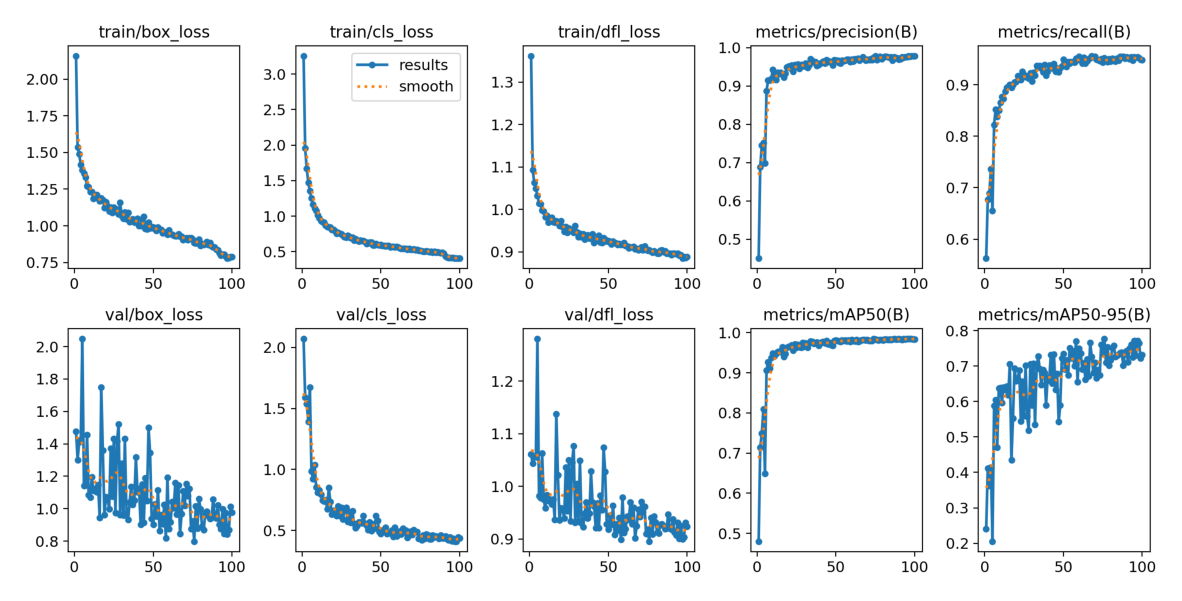

In [ ]:
metrics = cv2.imread(RUNS_PATH+'train/results.png')
metrics = cv2.cvtColor(metrics, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,12))
plt.imshow(metrics)
plt.axis('off')
plt.show()

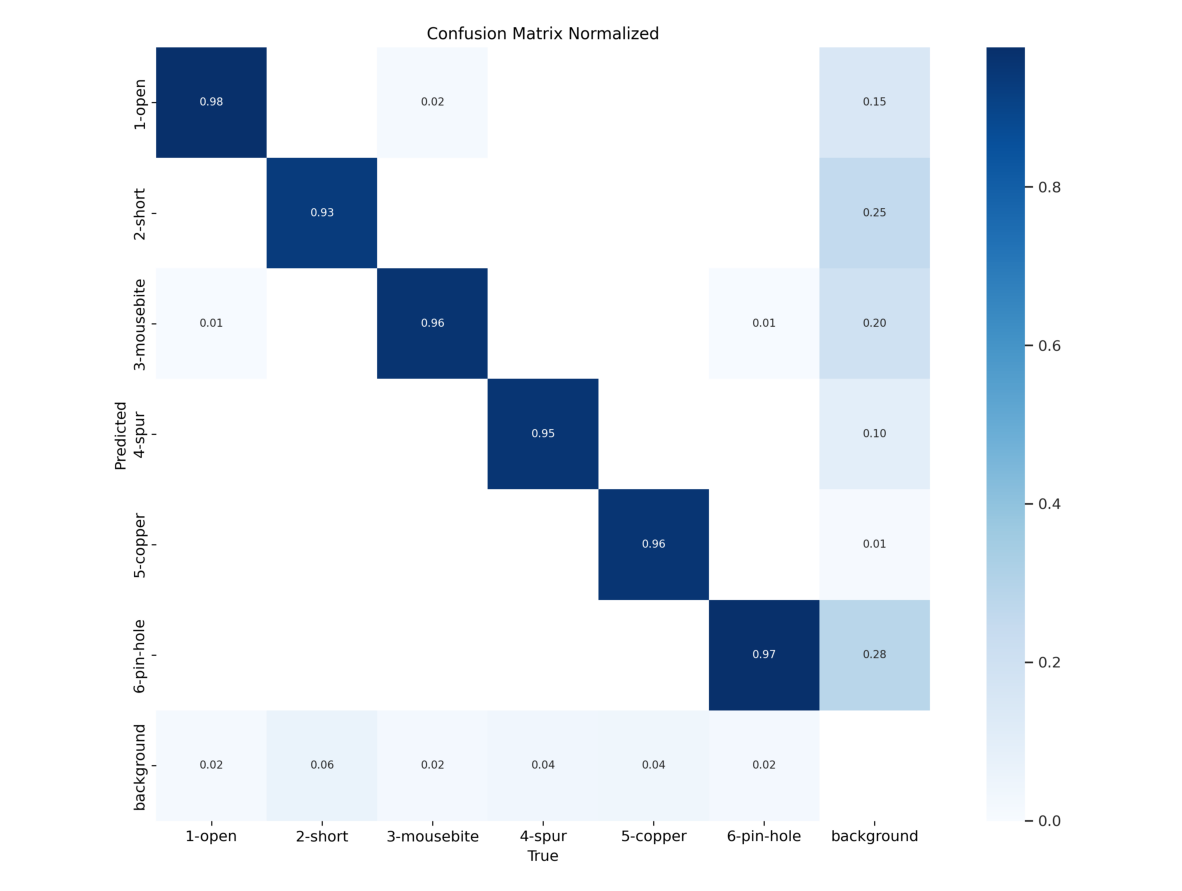

In [ ]:
metrics = cv2.imread(RUNS_PATH+'train/confusion_matrix_normalized.png')
metrics = cv2.cvtColor(metrics, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,12))
plt.imshow(metrics)
plt.axis('off')
plt.show()

## Model Inference

In [ ]:
load_model = YOLO(RUNS_PATH+'train/weights/best.pt')

path_1 = BASE_PATH+'val/images/00041003.jpg'
path_2 = BASE_PATH+'val/images/12100189.jpg'

predict_1 = load_model.predict(path_1)
predict_2 = load_model.predict(path_2)


image 1/1 /content/sample_data/val/images/00041003.jpg: 640x640 1 1-open, 2 3-mousebites, 1 5-copper, 2 6-pin-holes, 8.7ms
Speed: 1.6ms preprocess, 8.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/sample_data/val/images/12100189.jpg: 640x640 1 1-open, 1 2-short, 2 3-mousebites, 2 5-coppers, 1 6-pin-hole, 13.9ms
Speed: 1.9ms preprocess, 13.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


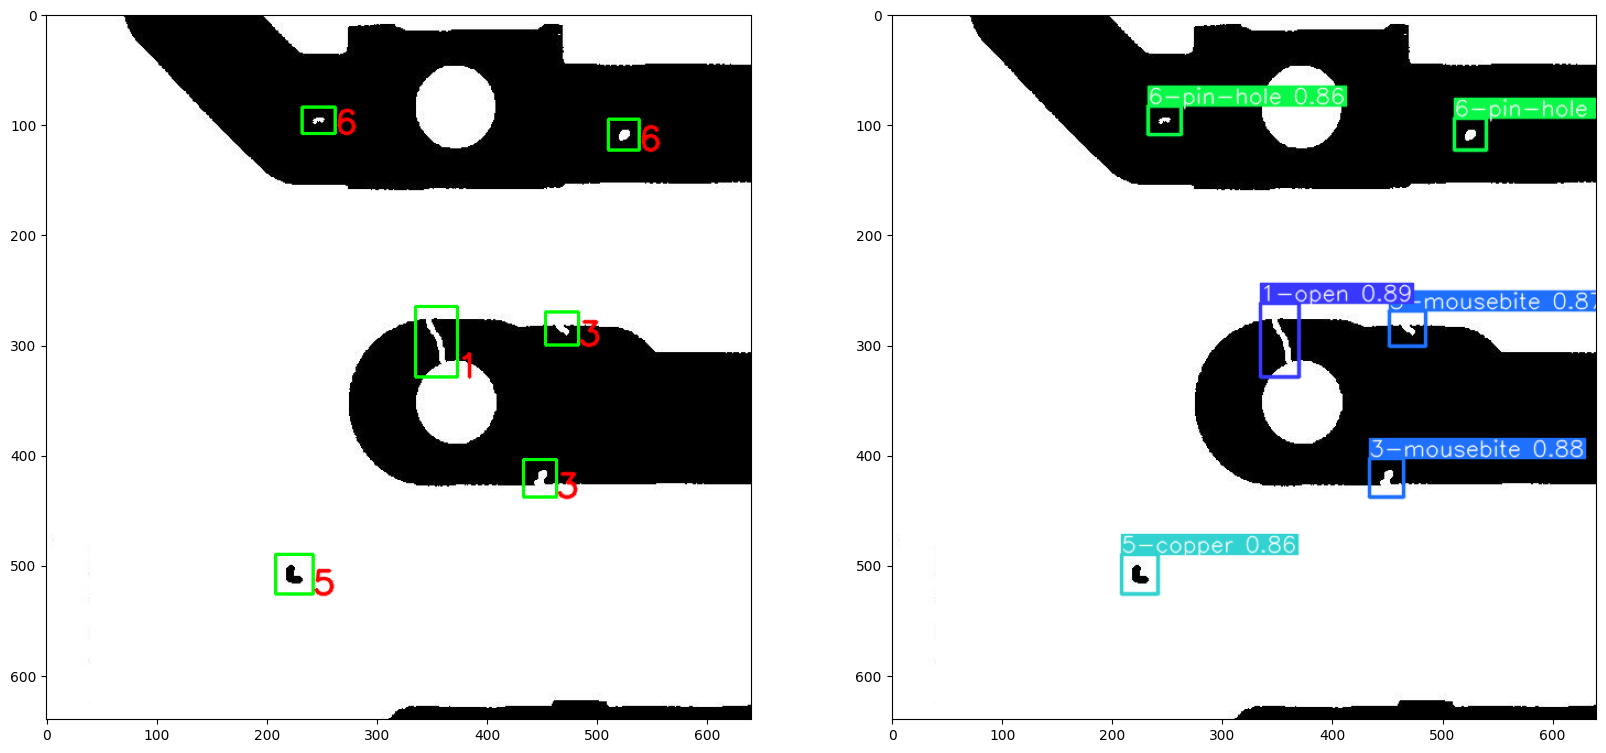

In [ ]:
image = cv2.imread(path_1)
h,w,c = image.shape

with open(BASE_PATH+'val/labels/00041003.txt', 'r') as file:
    details = file.readlines()

for detail in details:

    splitted = detail.split()
    xc = int(float(splitted[1])*w)
    yc = int(float(splitted[2])*h)
    wy = int((float(splitted[3])*w)/2)
    hy = int((float(splitted[4])*h)/2)
    label = str(int(splitted[0])+1)

    rectangle_image = cv2.rectangle(image, (xc - wy,yc - hy), (xc + wy,yc + hy), (0,255,0), 2)
    cv2.putText(image, label, (xc+wy, yc+hy), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2, cv2.LINE_AA)

fig, axs = plt.subplots(1,2, figsize=(20,20))


axs[0].imshow(rectangle_image)
axs[1].imshow(predict_1[0].plot())
plt.show()

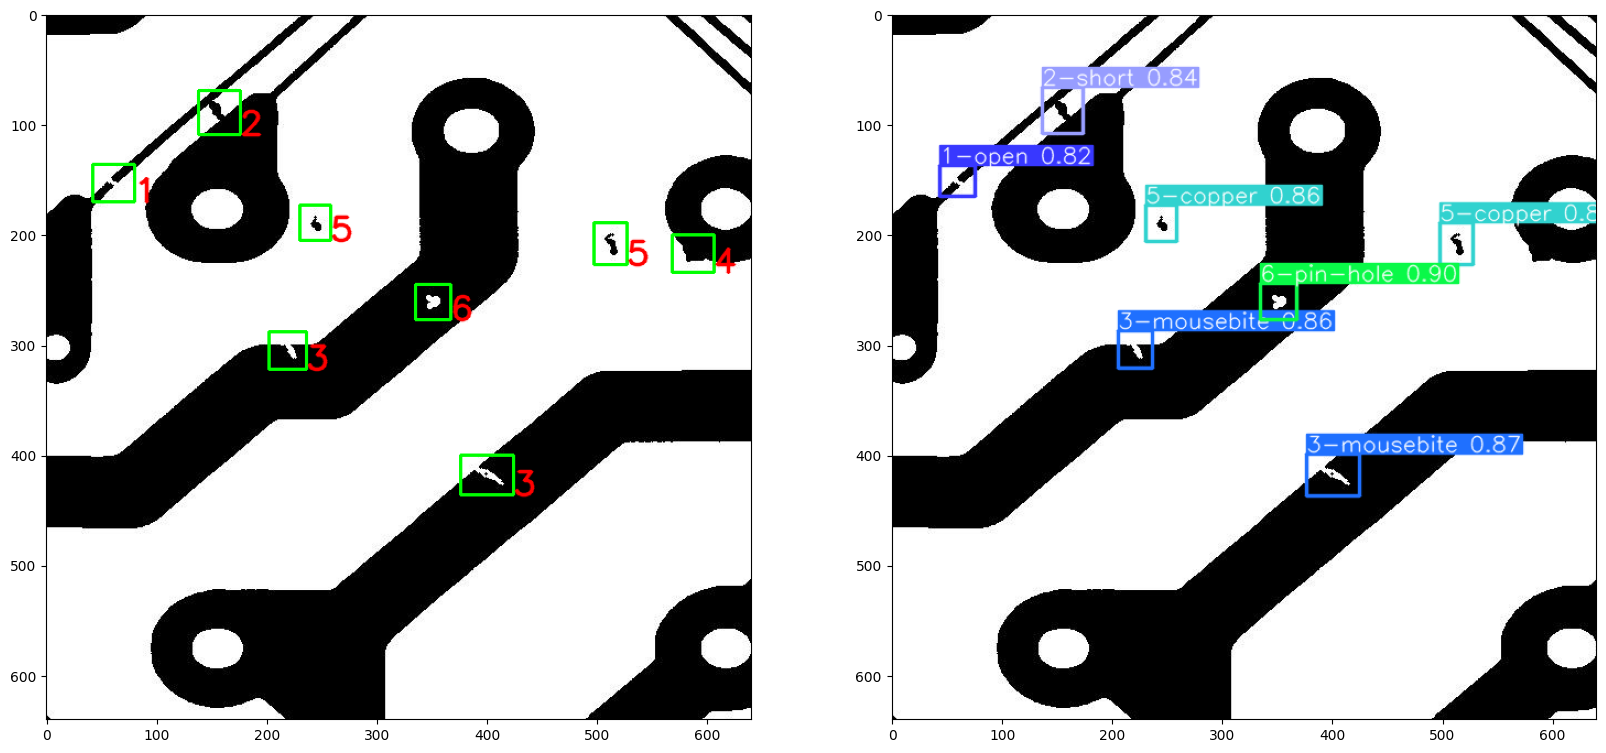

In [ ]:
image = cv2.imread(path_2)
h,w,c = image.shape

with open(BASE_PATH+'val/labels/12100189.txt', 'r') as file:
    details = file.readlines()

for detail in details:

    splitted = detail.split()
    xc = int(float(splitted[1])*w)
    yc = int(float(splitted[2])*h)
    wy = int((float(splitted[3])*w)/2)
    hy = int((float(splitted[4])*h)/2)
    label = str(int(splitted[0])+1)

    rectangle_image = cv2.rectangle(image, (xc - wy,yc - hy), (xc + wy,yc + hy), (0,255,0), 2)
    cv2.putText(image, label, (xc+wy, yc+hy), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2, cv2.LINE_AA)

fig, axs = plt.subplots(1,2, figsize=(20,20))


axs[0].imshow(rectangle_image)
axs[1].imshow(predict_2[0].plot())
plt.show()

#Assignment

Objetivos:
- Plotear las diferentes métricas de train que aparecen en la carpeta de runs
- Explicar en una celda de texto cada métrica que se plotee
- Hacer el test de evaluacón en todas las fotos

Deadline: